In [5]:
from pathlib import Path

# Ruta base del proyecto
BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")

# Rutas de entrada/salida
RAW = BASE / "data" / "raw"
DATA = BASE / "data"
FAA_DIR = "/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fasta/prodigal_results"            # más adelante guardaremos aquí los .faa
RES = BASE / "results" / "wgrr_pairs"


print(f"BASE = {BASE}")
print(f"RAW exists: {RAW.exists()}")
print(f"→ plsdb_mob.csv:", (RAW/"plsdb_mob.csv").exists())
print(f"→ plsdb_summary.csv:", (RAW/"plsdb_summary.csv").exists())


BASE = /home/nacho/HDD16/Nacho/RepliCOOC
RAW exists: True
→ plsdb_mob.csv: True
→ plsdb_summary.csv: True


In [6]:
import pandas as pd, re
from pathlib import Path

# --- rutas base ---
BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RAW  = BASE / "data" / "raw"
DATA = BASE / "data"
DATA.mkdir(exist_ok=True, parents=True)

mob_path  = RAW / "plsdb_mob.csv"
summ_path = RAW / "plsdb_summary.csv"

mob  = pd.read_csv(mob_path, dtype=str).fillna("")
summ = pd.read_csv(summ_path, dtype=str).fillna("")

print(f"{len(mob):,} plasmids in mob, {len(summ):,} in summary")

# --- función limpia: separador SOLO coma ---
def clean_rep(s: str) -> str:
    if not isinstance(s, str) or not s.strip():
        return ""
    # separa solo por coma, quita espacios, duplicados preservando orden
    items = [x.strip() for x in s.split(",") if x.strip()]
    seen = []
    for x in items:
        if x not in seen:
            seen.append(x)
    return ",".join(seen)

# --- construir tabla base ---
meta = mob.rename(columns={"NUCCORE_ACC": "plasmid_id"}).copy()
meta["replicon_types"] = meta["rep_type"].map(clean_rep)
meta = meta[["plasmid_id", "replicon_types"]].drop_duplicates()

# placeholder para faa
meta["faa"] = ""

# opcional: añadir tamaño si está disponible en summary
if any(c.lower().startswith("size") for c in summ.columns):
    size_col = [c for c in summ.columns if c.lower().startswith("size")][0]
    sizes = summ.rename(columns={size_col: "size_bp"})[["Accession", "size_bp"]]
    sizes = sizes.rename(columns={"Accession": "plasmid_id"})
    meta = meta.merge(sizes, on="plasmid_id", how="left")
else:
    meta["size_bp"] = None

# --- contar replicones ---
meta["n_replicons"] = meta["replicon_types"].apply(
    lambda x: len(x.split(",")) if isinstance(x, str) and x else 0
)

# --- exportar ---
out_path = DATA / "plasmid_replicons.tsv"
meta.to_csv(out_path, sep="\t", index=False)
print(f"✅ plasmid_replicons.tsv creado correctamente → {out_path}")
print(meta.head(10))


72,360 plasmids in mob, 72,360 in summary
✅ plasmid_replicons.tsv creado correctamente → /home/nacho/HDD16/Nacho/RepliCOOC/data/plasmid_replicons.tsv
      plasmid_id                     replicon_types faa size_bp  n_replicons
0  NZ_CP139252.1  rep_cluster_1226,rep_cluster_2359        None            2
1  NZ_CP139269.1                   rep_cluster_1226        None            1
2  NZ_CP139268.1                                           None            0
3  NZ_CP139267.1                   rep_cluster_1218        None            1
4  NZ_CP139215.1                    rep_cluster_125        None            1
5  NZ_CP139274.1                   rep_cluster_1172        None            1
6  NZ_CP139273.1                   rep_cluster_1226        None            1
7  NZ_CP139272.1                    rep_cluster_639        None            1
8  NZ_CP139271.1                    rep_cluster_718        None            1
9  NZ_CP139281.1                                           None            0


In [7]:
# Si summary tiene tamaños, los añadimos
if "Size" in summ.columns:
    size_col = "Size"
elif "Size (bp)" in summ.columns:
    size_col = "Size (bp)"
else:
    size_col = None

meta = pd.read_csv(DATA / "plasmid_replicons.tsv", sep="\t")
if size_col:
    sizes = summ.rename(columns={size_col: "size_bp"})[["Accession", "size_bp"]]
    sizes = sizes.rename(columns={"Accession": "plasmid_id"})
    meta = meta.merge(sizes, on="plasmid_id", how="left")
else:
    meta["size_bp"] = None

# contar número de replicones
meta["n_replicons"] = meta["replicon_types"].apply(lambda s: len(s.split("+")) if isinstance(s,str) and s else 0)
meta.to_csv(DATA / "plasmid_replicons.tsv", sep="\t", index=False)
print("🔢 n_replicons añadido. Ejemplo:")
print(meta.head(3))


🔢 n_replicons añadido. Ejemplo:
      plasmid_id                     replicon_types  faa size_bp  n_replicons
0  NZ_CP139252.1  rep_cluster_1226,rep_cluster_2359  NaN    None            1
1  NZ_CP139269.1                   rep_cluster_1226  NaN    None            1
2  NZ_CP139268.1                                NaN  NaN    None            0


In [8]:
import pandas as pd, re, glob
from pathlib import Path

BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
DATA = BASE / "data"
FAA_DIR = BASE / "data" / "raw" / "fasta" / "prodigal_results"  # donde dijiste que están

# 1) Listar archivos .faa
faa_files = list(FAA_DIR.glob("*.faa"))
print(f"Encontrados {len(faa_files)} archivos .faa en {FAA_DIR}")

# 2) Mapa exacto por stem: 'NZ_CP139252.1' → '/.../NZ_CP139252.1.faa'
faa_map_exact = {p.stem: str(p) for p in faa_files}

# 3) Cargar meta con tipos de datos como string y sin NaNs
meta = pd.read_csv(DATA / "plasmid_replicons.tsv", sep="\t", dtype=str).fillna("")
# Asegura que n_replicons es int si existe
if "n_replicons" in meta.columns:
    meta["n_replicons"] = pd.to_numeric(meta["n_replicons"], errors="coerce").fillna(0).astype(int)

# 4) Asignación primaria (match exacto por stem)
meta["faa"] = meta["plasmid_id"].map(faa_map_exact).fillna("")

# 5) Fallback: si no hay match exacto, buscar archivos cuyo nombre contenga el accession
def find_fallback(acc):
    if not acc:
        return ""
    cands = [p for p in faa_files if acc in p.name]
    if len(cands) == 1:
        return str(cands[0])
    # si hay múltiples, intenta priorizar el que empiece con el accession
    prefer = [p for p in cands if p.name.startswith(acc)]
    if len(prefer) >= 1:
        return str(sorted(prefer, key=lambda x: len(x.name))[0])
    return ""  # sin asignar

mask_missing = meta["faa"] == ""
if mask_missing.any():
    meta.loc[mask_missing, "faa"] = meta.loc[mask_missing, "plasmid_id"].map(find_fallback).fillna("")

# 6) Reporte
n_assigned = (meta["faa"] != "").sum()
n_total = len(meta)
print(f"🧬 FAA asignados: {n_assigned}/{n_total} ({n_assigned/n_total:.1%})")

if n_assigned < n_total:
    faltan = meta.loc[meta["faa"] == "", "plasmid_id"].head(20).tolist()
    print("⚠️ Plásmidos sin .faa (primeros 20):", faltan)

# 7) Guardar
meta.to_csv(DATA / "plasmid_replicons.tsv", sep="\t", index=False)
meta.head(3)


Encontrados 72536 archivos .faa en /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fasta/prodigal_results
🧬 FAA asignados: 72352/72360 (100.0%)
⚠️ Plásmidos sin .faa (primeros 20): ['NZ_CP135269.1', 'NZ_CP082052.1', 'NZ_AP027617.1', 'NZ_OY725800.1', 'CP101347.1', 'NZ_CP101699.1', 'NZ_CP020583.1', 'AF318175.1']


,plasmid_id,replicon_types,faa,size_bp,n_replicons
0,NZ_CP139252.1,"rep_cluster_1226,rep_cluster_2359",/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,,1
1,NZ_CP139269.1,rep_cluster_1226,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,,1
2,NZ_CP139268.1,,/home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...,,0


In [9]:
import pandas as pd
from pathlib import Path

BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
DATA = BASE / "data"
RES  = BASE / "results" / "wgrr_pairs"
DB   = RES / "mmseqs_db"
OUT  = RES / "mmseqs_out"
TMP  = RES / "tmp"
LOG  = RES / "logs"
for d in [RES, DB, OUT, TMP, LOG]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------- cargar tabla base -------------------
meta = pd.read_csv(DATA / "plasmid_replicons.tsv", sep="\t", dtype=str).fillna("")

# recalcular n_replicons SOLO por comas
def count_replicons(repstr: str) -> int:
    if not isinstance(repstr, str) or not repstr.strip():
        return 0
    return len([x for x in repstr.split(",") if x.strip()])

meta["n_replicons"] = meta["replicon_types"].apply(count_replicons)

# convertir size_bp si existe
if "size_bp" in meta.columns:
    meta["size_bp"] = pd.to_numeric(meta["size_bp"], errors="coerce")

# asegurar que todas las rutas a faa existen
meta["faa"] = meta["faa"].fillna("")
meta = meta[meta["faa"] != ""]

# filtrar solo los que tienen n_replicons > 0
nodes = meta.query("n_replicons > 0").copy()

# ordenar por número de replicones (capa)
nodes = nodes.sort_values("n_replicons")

print(f"✅ Total en meta: {len(meta)} | Utilizables (con faa y n_replicons>0): {len(nodes)}")
print(nodes.head(5))

# ------------------- guardar nodes.tsv -------------------
nodes.to_csv(RES / "nodes.tsv", sep="\t", index=False)
print(f"✅ nodes.tsv escrito -> {RES/'nodes.tsv'}")


✅ Total en meta: 72352 | Utilizables (con faa y n_replicons>0): 53515
          plasmid_id    replicon_types  \
36164  NZ_CP110788.1  rep_cluster_1281   
43977  NZ_CP096709.1   rep_cluster_718   
43978  NZ_CP096708.1   rep_cluster_650   
43979  NZ_CP096770.1   rep_cluster_718   
43980  NZ_CP096769.1   rep_cluster_650   

                                                     faa  size_bp  n_replicons  
36164  /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...      NaN            1  
43977  /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...      NaN            1  
43978  /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...      NaN            1  
43979  /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...      NaN            1  
43980  /home/nacho/HDD16/Nacho/RepliCOOC/data/raw/fas...      NaN            1  
✅ nodes.tsv escrito -> /home/nacho/HDD16/Nacho/RepliCOOC/results/wgrr_pairs/nodes.tsv


In [10]:
from pathlib import Path
import pandas as pd, itertools
from collections import defaultdict

BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
RES  = BASE / "results" / "wgrr_pairs"

nodes = pd.read_csv(RES/"nodes.tsv", sep="\t", dtype=str).fillna("")
nodes["n_replicons"] = pd.to_numeric(nodes["n_replicons"], errors="coerce").fillna(0).astype(int)

def as_list(repstr: str):
    return [x.strip() for x in repstr.split(",") if x.strip()] if repstr else []

nodes["rep_list"] = nodes["replicon_types"].apply(as_list)

multi = nodes[(nodes["n_replicons"] >= 2) & (nodes["faa"] != "")]
cand  = nodes[(nodes["n_replicons"].isin([1,2])) & (nodes["faa"] != "")]

# índice EXACTO por composición (comas)
key = lambda lst: ",".join(lst)
cand_idx = defaultdict(list)
for r in cand.itertuples():
    cand_idx[key(r.rep_list)].append(r.plasmid_id)

pairs_path = RES / "pairs_multi_vs_subsets.tsv"
count_pairs = 0

with open(pairs_path, "w") as fh:
    fh.write("id1\tid2\tlayer1\tlayer2\tsubset_key\n")
    for r in multi.itertuples():
        reps = r.rep_list
        m = len(reps)  # tamaño del multi
        # tamaños de subconjunto permitidos:
        # - si m=2 -> k=1
        # - si m>=3 -> k=1,2
        ks = [1] if m == 2 else [1,2]
        for k in ks:
            if m < k: 
                continue
            for comb in itertools.combinations(reps, k):
                subkey = key(list(comb))
                targets = cand_idx.get(subkey, [])
                if not targets:
                    continue
                for subset_id in targets:
                    # ORDEN FORZADO: subset (pequeño) -> multi (grande)
                    id1 = subset_id            # pequeño (layer1=k)
                    id2 = r.plasmid_id         # grande  (layer2=m)
                    fh.write(f"{id1}\t{id2}\t{k}\t{m}\t{subkey}\n")
                    count_pairs += 1

print(f"✅ pairs_multi_vs_subsets.tsv (rehecho): {count_pairs:,} pares -> {pairs_path}")


✅ pairs_multi_vs_subsets.tsv (rehecho): 26,544,732 pares -> /home/nacho/HDD16/Nacho/RepliCOOC/results/wgrr_pairs/pairs_multi_vs_subsets.tsv


In [11]:
# === Carga y helpers ===
from pathlib import Path
import pandas as pd
import networkx as nx

BASE = Path("/home/nacho/HDD16/Nacho/RepliCOOC")
WORK = BASE / "results/mr_vs_familyspace"

meta = pd.read_csv(WORK/"meta_min.tsv", sep="\t", dtype=str)  # plasmid_id, combo, is_multi
matches = pd.read_csv(WORK/"mr_vs_familyspace_matches.tsv", sep="\t", dtype=str)

# Solo capas hasta 4 replicones
def combo_to_set(s: str):
    if pd.isna(s) or s == "NA" or s == "":
        return frozenset()
    return frozenset(s.split("|"))

meta["combo_set"] = meta["combo"].map(combo_to_set)
meta["layer"] = meta["combo_set"].map(len)

# Normaliza y castea campos clave de matches
for c in ["k","ref_size","n_genes","n_present","threshold"]:
    if c in matches.columns:
        matches[c] = pd.to_numeric(matches[c], errors="coerce")
matches["fraction_present"] = pd.to_numeric(matches["fraction_present"], errors="coerce")

# Diccionarios útiles
id2combo = dict(zip(meta["plasmid_id"], meta["combo_set"]))
id2layer = dict(zip(meta["plasmid_id"], meta["layer"]))
id2ismulti = dict(zip(meta["plasmid_id"], meta["is_multi"]))



KeyboardInterrupt



In [3]:
# === Construye grafo dirigido multicapa ===
G = nx.DiGraph()

# Filtra matches válidos (contenidos ≥90%)
valid = matches[matches["fully_present_>=threshold"] == "YES"].copy()

# Añade columnas de capas y combos reales (recomprobamos subconjunto)
valid["mr_layer"]  = valid["MR_id"].map(id2layer)
valid["ref_layer"] = valid["REF_id"].map(id2layer)
valid["mr_combo"]  = valid["MR_id"].map(id2combo)
valid["ref_combo"] = valid["REF_id"].map(id2combo)

def is_subset(row):
    a = row["ref_combo"]
    b = row["mr_combo"]
    return (a is not None) and (b is not None) and (len(a) < len(b)) and a.issubset(b)

valid = valid[
    valid["mr_layer"].fillna(0).astype(int).le(4) &
    valid.apply(is_subset, axis=1)
].copy()

# Crea nodos con atributos (layer, tipo)
def add_node(pid):
    if pid not in G:
        G.add_node(
            pid,
            layer=int(id2layer.get(pid, 0)),
            is_multi=(id2ismulti.get(pid, "0") in ("1","TRUE","true","multi")),
            combo="|".join(sorted(id2combo.get(pid, set()))),
        )

# === Añade nodos y aristas (con n_present y n_genes) ===
for _, r in valid.iterrows():
    ref_id = r["REF_id"]
    mr_id  = r["MR_id"]
    add_node(ref_id)
    add_node(mr_id)

    # Extrae valores si existen
    frac = float(r.get("fraction_present", 0.0) or 0.0)
    ref_size = int(r.get("ref_size", 0) or 0)
    mr_k     = int(r.get("k", 0) or 0)
    n_genes  = int(r.get("n_genes", 0) or 0)
    n_present = int(r.get("n_present", 0) or 0)

    G.add_edge(
        ref_id, mr_id,
        frac=frac,
        ref_size=ref_size,
        mr_size=mr_k,
        n_genes=n_genes,
        n_present=n_present,
        kind="contained"
    )

print(nx.info(G))



AttributeError: module 'networkx' has no attribute 'info'

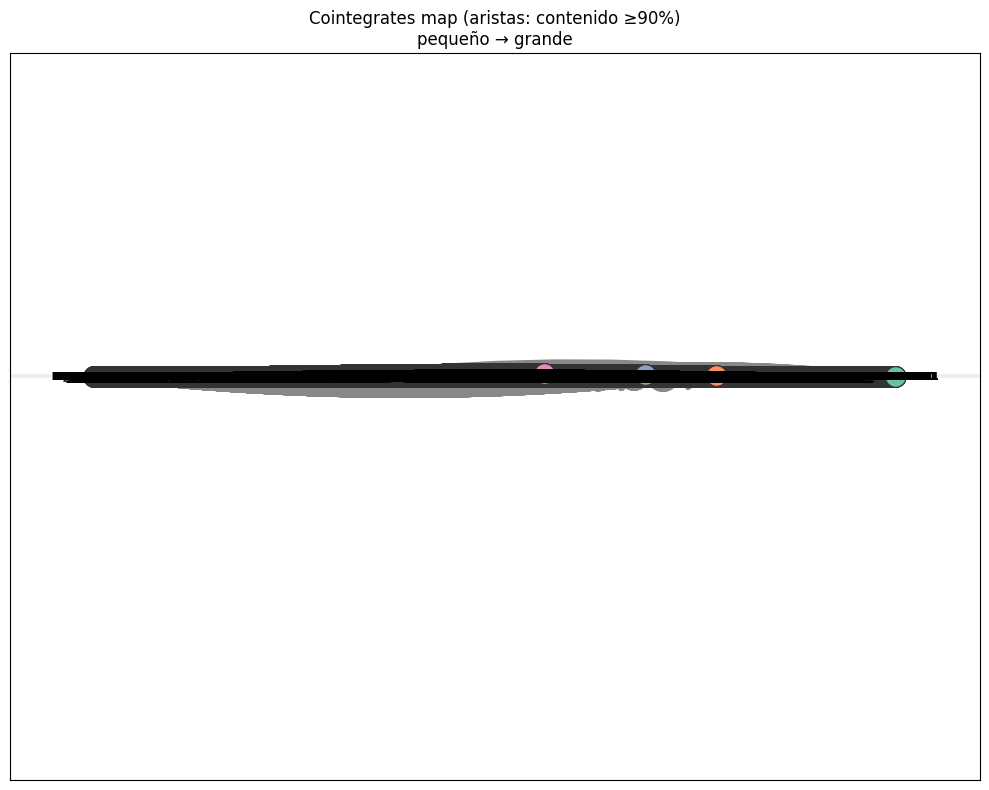

In [16]:
# === Layout por capas (y=layer), dibujo con matplotlib ===
import math
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)

# Agrupa nodos por capa
from collections import defaultdict
by_layer = defaultdict(list)
for n, d in G.nodes(data=True):
    by_layer[d["layer"]].append(n)

# Posiciones
pos = {}
x_pad = 1.5
for layer, nodes in sorted(by_layer.items()):
    n = len(nodes)
    if n == 0: 
        continue
    # posiciones X equiespaciadas centradas
    xs = [ (i - (n-1)/2.0)*x_pad for i in range(n) ]
    for x, node in zip(xs, nodes):
        pos[node] = (x, layer)

# Colores por capa
layer_colors = {1:"#66c2a5", 2:"#fc8d62", 3:"#8da0cb", 4:"#e78ac3"}
node_colors  = [ layer_colors.get(G.nodes[n]["layer"], "#c7c7c7") for n in G.nodes() ]

# Ancho de aristas por fracción
edges = list(G.edges(data=True))
edge_widths = [ max(0.5, 4.0*e[2]["frac"]) for e in edges ]

# Dibujo
plt.figure()
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=220, linewidths=0.8, edgecolors="#333333")
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold",
                        labels={n: n for n in G.nodes()})

nx.draw_networkx_edges(
    G, pos, arrows=True, arrowstyle="->", arrowsize=12,
    width=edge_widths, edge_color="#888888", connectionstyle="arc3,rad=0.06"
)

# Ejes: capas
for y in [1,2,3,4]:
    plt.axhline(y, color="#eeeeee", lw=0.8, zorder=0)
plt.yticks([1,2,3,4], ["1-rep","2-rep","3-rep","4-rep"])
plt.xticks([])
plt.title("Cointegrates map (aristas: contenido ≥90%)\npequeño → grande", fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# === Interactivo con PyVis ===
from pyvis.network import Network
import json

# Inicialización del grafo interactivo
net = Network(height="750px", width="100%", directed=True, notebook=True)
net.barnes_hut(
    gravity=-2000,
    central_gravity=0.3,
    spring_length=120,
    spring_strength=0.02
)

# Añadimos nodos
for n, d in G.nodes(data=True):
    layer = d["layer"]
    color = layer_colors.get(layer, "#c7c7c7")
    title = f"{n}<br>combo={d['combo']}<br>layer={layer}<br>is_multi={d['is_multi']}"
    net.add_node(
        n,
        label=n,
        title=title,
        color=color,
        level=layer,  # para multilayer levels
        physics=True,
        shape="dot",
        size=12
    )

# Añadimos aristas
for u, v, a in G.edges(data=True):
    frac = a.get("frac", 0.0)
    w = max(1, int(8 * frac))
    title = f"{u} → {v}<br>fraction_present={frac:.2f}"
    net.add_edge(
        u,
        v,
        value=w,
        width=w,
        title=title,
        arrows="to",
        color="#555555"
    )

# Configuración visual (en formato JSON correcto)
options = {
    "layout": {
        "hierarchical": {
            "enabled": True,
            "direction": "UD",
            "sortMethod": "hubsize",
            "levelSeparation": 140,
            "nodeSpacing": 120
        }
    },
    "physics": {
        "enabled": True,
        "stabilization": {"iterations": 250}
    },
    "edges": {
        "smooth": {"type": "dynamic"}
    }
}

net.set_options(json.dumps(options))

# Mostrar / guardar
html_path = str(WORK / "multilayer_plasmids.html")
net.show(html_path)
html_path


/home/nacho/HDD16/Nacho/RepliCOOC/results/mr_vs_familyspace/multilayer_plasmids.html


'/home/nacho/HDD16/Nacho/RepliCOOC/results/mr_vs_familyspace/multilayer_plasmids.html'

In [19]:
# === Filtra a nodos con al menos una arista (in-degree + out-degree > 0) ===
import pandas as pd

nodes_with_edges = [n for n in G.nodes() if G.degree(n) > 0]
H = G.subgraph(nodes_with_edges).copy()

# Tabla compacta: solo plasmidios conectados
rows = []
for n, d in H.nodes(data=True):
    rows.append({
        "plasmid_id": n,
        "combo": d.get("combo",""),
        "layer": d.get("layer",0),
        "in_deg": H.in_degree(n),
        "out_deg": H.out_degree(n)
    })
tab = pd.DataFrame(rows).sort_values(["layer","plasmid_id"]).reset_index(drop=True)

# Muestra solo conectados
tab
# === Interactivo con PyVis (solo subgrafo H, nodos conectados) ===
from pyvis.network import Network
import json

net = Network(height="750px", width="100%", directed=True, notebook=True)
net.barnes_hut(gravity=-2000, central_gravity=0.3, spring_length=120, spring_strength=0.02)

# Añadimos nodos (conectados)
for n, d in H.nodes(data=True):
    layer = d["layer"]
    color = layer_colors.get(layer, "#c7c7c7")
    title = f"{n}<br>combo={d['combo']}<br>layer={layer}<br>in={H.in_degree(n)} out={H.out_degree(n)}"
    net.add_node(n, label=n, title=title, color=color, level=layer, physics=True, shape="dot", size=12)

# Añadimos aristas
for u, v, a in H.edges(data=True):
    frac = a.get("frac", 0.0)
    w = max(1, int(8 * frac))
    title = f"{u} → {v}<br>fraction_present={frac:.2f}"
    net.add_edge(u, v, value=w, width=w, title=title, arrows="to", color="#555555")

# Opciones (JSON válido)
options = {
    "layout": {"hierarchical": {"enabled": True, "direction": "UD", "sortMethod": "hubsize",
                                "levelSeparation": 140, "nodeSpacing": 120}},
    "physics": {"enabled": True, "stabilization": {"iterations": 250}},
    "edges": {"smooth": {"type": "dynamic"}}
}
net.set_options(json.dumps(options))

html_path = str(WORK / "multilayer_plasmids_connected.html")
net.show(html_path)
html_path


/home/nacho/HDD16/Nacho/RepliCOOC/results/mr_vs_familyspace/multilayer_plasmids_connected.html


'/home/nacho/HDD16/Nacho/RepliCOOC/results/mr_vs_familyspace/multilayer_plasmids_connected.html'

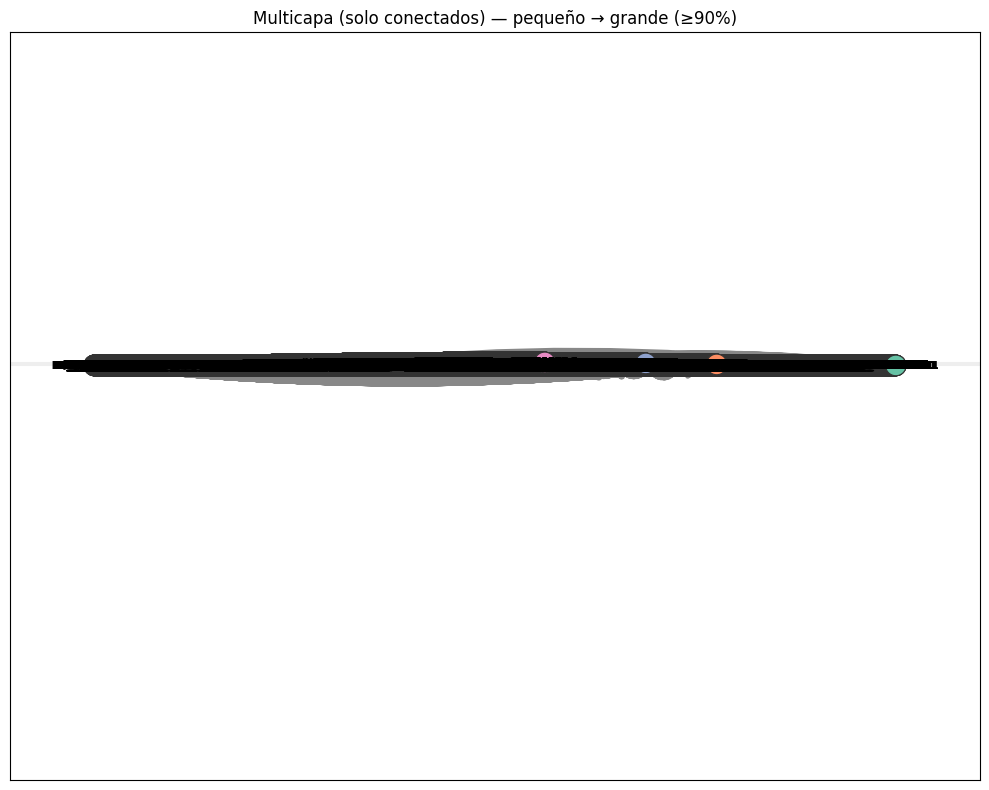

In [20]:
# === Layout y dibujo estático con matplotlib usando H ===
import matplotlib.pyplot as plt
from collections import defaultdict

by_layer = defaultdict(list)
for n, d in H.nodes(data=True):
    by_layer[d["layer"]].append(n)

pos = {}
x_pad = 1.5
for layer, nodes in sorted(by_layer.items()):
    xs = [ (i - (len(nodes)-1)/2.0)*x_pad for i in range(len(nodes)) ]
    for x, node in zip(xs, nodes):
        pos[node] = (x, layer)

node_colors = [ layer_colors.get(H.nodes[n]["layer"], "#c7c7c7") for n in H.nodes() ]
edges = list(H.edges(data=True))
edge_widths = [ max(0.5, 4.0*e[2]["frac"]) for e in edges ]

plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=220, linewidths=0.8, edgecolors="#333")
nx.draw_networkx_labels(H, pos, font_size=7, font_weight="bold")
nx.draw_networkx_edges(H, pos, arrows=True, arrowstyle="->", arrowsize=12,
                       width=edge_widths, edge_color="#888", connectionstyle="arc3,rad=0.06")
for y in [1,2,3,4]:
    plt.axhline(y, color="#eee", lw=0.8, zorder=0)
plt.yticks([1,2,3,4], ["1-rep","2-rep","3-rep","4-rep"])
plt.xticks([])
plt.title("Multicapa (solo conectados) — pequeño → grande (≥90%)", fontsize=12)
plt.tight_layout(); plt.show()


In [4]:
# === Tabla de aristas "pequeño → grande (MR que contiene)" ===
import pandas as pd

rows = []
for u, v, a in G.edges(data=True):
    du, dv = G.nodes[u], G.nodes[v]
    # destino debe ser multirreplicón; origen debe tener menos replicones
    if not dv.get("is_multi", False):
        continue
    if int(du.get("layer", 0)) >= int(dv.get("layer", 0)):
        continue

    frac = float(a.get("frac", 0.0))
    ref_size = int(a.get("ref_size", du.get("layer", 0)))  # capa del pequeño
    mr_k     = int(a.get("mr_size",  dv.get("layer", 0)))  # capa del grande

    # etiqueta del tipo de candidato (single vs k-1)
    if ref_size == 1:
        cand_type = "single"
    elif ref_size == mr_k - 1:
        cand_type = "k-1"
    else:
        cand_type = f"{ref_size}-rep"

    rows.append({
        "small_id": u,
        "small_combo": du.get("combo",""),
        "small_n_replicons": int(du.get("layer", 0)),
        "big_id": v,
        "big_combo": dv.get("combo",""),
        "big_n_replicons": int(dv.get("layer", 0)),
        "fraction_present": frac,
        "n_present": a.get("n_present", None),
        "n_genes": a.get("n_genes", None),
        "candidate_type": cand_type  # single / k-1 / otro
    })

edges_df = (pd.DataFrame(rows)
              .sort_values(["big_n_replicons","big_id","fraction_present"], ascending=[True, True, False])
              .reset_index(drop=True))

# Mostrar y guardar
display(edges_df.head(20))
out_edges = WORK / "edges_containment.tsv"
edges_df.to_csv(out_edges, sep="\t", index=False)

print(f"✅ Tabla escrita en: {out_edges}")
print(f"📎 Aristas (small→big MR): {len(edges_df)};  N nodos conectados: {len(G.nodes())}")


,small_id,small_combo,small_n_replicons,big_id,big_combo,big_n_replicons,fraction_present,n_present,n_genes,candidate_type
0,NZ_AP026098.1,IncFIA,1,AB011549.2,IncFIA|IncFIB,2,0.983,58,59,single
1,AB576781.2,IncFII,1,AB605179.1,IncFIB|IncFII,2,0.993,138,139,single
2,JF274991.1,IncFII,1,AB605179.1,IncFIB|IncFII,2,0.993,137,138,single
3,CP082474.1,IncFII,1,AB605179.1,IncFIB|IncFII,2,0.965,110,114,single
4,AB576781.2,IncFII,1,AP014566.1,IncFIB|IncFII,2,0.978,136,139,single
5,JF274991.1,IncFII,1,AP014566.1,IncFIB|IncFII,2,0.978,135,138,single
6,CP082474.1,IncFII,1,AP014566.1,IncFIB|IncFII,2,0.965,110,114,single
7,NZ_MG197500.1,IncFIA,1,AP018568.2,IncFIA|IncN,2,0.914,74,81,single
8,NZ_MG197501.1,IncFIA,1,AP018568.2,IncFIA|IncN,2,0.914,74,81,single
9,NZ_CP024823.1,IncFIA,1,AP018568.2,IncFIA|IncN,2,0.909,70,77,single


✅ Tabla escrita en: /home/nacho/HDD16/Nacho/RepliCOOC/results/mr_vs_familyspace/edges_containment.tsv
📎 Aristas (small→big MR): 135181;  N nodos conectados: 17829
